In [1]:
import sys
import os

# 현재 작업 디렉터리를 기준으로 utils 경로 추가
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'utils')))

from data_utils import *  # utils/data_utils.py

# 중심성 지표 가져오기 : central_df

In [2]:
import pandas as pd
from neo4j import GraphDatabase

# Neo4j connection parameters
uri = "bolt://localhost:7687"
auth = ("neo4j", "neo4j1234")
database = "orders"

# Initialize driver
driver = GraphDatabase.driver(uri, auth=auth)

# List of store IDs for which metrics were computed
store_ids = [3, 5, 10028]

# Collect rows
rows = []

with driver.session(database=database) as session:
    for store_id in store_ids:
        # Cypher to fetch metrics for this store_id
        query = f"""
        MATCH (c:Customers)
        WHERE c.pagerank_{store_id} IS NOT NULL
        RETURN
          c.id AS customerId,
          {store_id} AS storeId,
          c.pagerank_{store_id} AS pagerank,
          c.degree_{store_id} AS degree,
          c.betweenness_{store_id} AS betweenness,
          c.closeness_{store_id} AS closeness,
          c.eigen_{store_id} AS eigen,
          c.community_{store_id} AS community
        """
        result = session.run(query)
        for record in result:
            rows.append(dict(record))

driver.close()

# Create DataFrame
central_df = pd.DataFrame(rows)

# Display to user
display(central_df)

,customerId,storeId,pagerank,degree,betweenness,closeness,eigen,community
0,01H7MCFH99MSQ0RXEREYY77XPT,3,0.96124,1.0,0.0,1.0,0.009046,1
1,01H7MDNCH41780VJNTHZHWYQT0,3,0.96124,1.0,0.0,1.0,0.009046,1
2,01H7MF38PVYVJ8NV47H9W0PT60,3,0.96124,1.0,0.0,1.0,0.009046,3
3,01H7MGF57GXKKXAFM224MVFMM5,3,0.96124,1.0,0.0,1.0,0.009046,3
4,01H7MQP5TK1XRZ258WYVS1ZG57,3,0.96124,1.0,0.0,1.0,0.009046,5
...,...,...,...,...,...,...,...,...
22218,01JV6CJ4F1C9DMFX6HB2SQGX0V,10028,0.96124,1.0,0.0,1.0,0.009745,9437
22219,01JV6CM23YS0EMN95H1XHK0VJ2,10028,0.96124,3.0,0.0,1.0,0.009745,9439
22220,01JV6CM24Q2TP3QK05RBJMN38T,10028,0.96124,3.0,0.0,1.0,0.009745,9439
22221,01JV6CM25Q7TVPG8NY3SH962Q6,10028,0.96124,3.0,0.0,1.0,0.009745,9439


In [3]:
pd.set_option('display.max_rows', None)

In [4]:
central_df.isna().sum()

customerId     0
storeId        0
pagerank       0
degree         0
betweenness    0
closeness      0
eigen          0
community      0
dtype: int64

# orders 정보 가져오기 : visit_df

In [5]:
import pandas as pd
from sqlalchemy import create_engine

# ── 0. MySQL 접속 ────────────────────
# 실제 접속 정보로 아래 값을 수정하세요.
DB_USER = "dev"
DB_PASS = "pwd"
DB_HOST = "localhost"
DB_PORT = "3307"
DB_NAME = "orders"

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# ── 제외할 customerId 목록 ──────────────────────────────
excluded_ids = [
    '01H8K9XWK972V31SN3HDRGY022','01H7S6309C3ZWPVVMAWDYQDQE9',
    '01H7JEGZX7C0NCPN8ZZ3AJXASE','01H7YB33EPCWHTX1WWA9ANJCPG',
    '01H7VSQW5TB8Q4HR1Z4S5CTJKQ','01H4001EP0F1859987V7D4YJFG',
    '01H8DZZ71SYRKB4868B0WHV68E','01H98VZ8Y98MJ489TEJW7QCDS4',
    '01H7S0P3HK62VATNYDHADQPHKJ','01H9A1GTJVCTA13SA9YPEB9ETA',
    '01H7QY348FZQRVP21JAN8X4Z7R','01H7S9MDFE2FW13DPP93DV0WWP',
    '01H7SVW6ECGZ5JXPSV0YS6P7KG','01H7J0A52BKC867SHMNBZ85XTC',
    '01H847J2DGX5KEKMX386TKYGY1','01H7HNC3GKV65TAG2H3SGW7A0H',
    '01H98W8WA1X2E09TZ50DHHRJSA','01H59HRM9W7WZC0Y0Y5YK4ZJS8',
    '01H7HTY1JNFB3H0MP72X5R4QJW','01H7QXJZ7MQ63FTGJTJ5WB5TFR',
    '01H98VE7QSYH0W7AFH9Z9RY6KZ','01H3ZY9J55GM6S18YQGR3DCGQT',
    '01H8Y02HDQZTAH5AVKP51RN05G','01H847HNN73J8V4DN1V1Z7QJTT',
    '01GZZ0C5HVG9049C8AT5Y96HFS','01H9MSJKX4CCDBG2JK327BSP84',
    '01H9MAY8ZDX7KMFBS7EJYJR5AF','01HFDTAW1QRVR8P1HDKH4CNM47',
    '01HF8FYGWYH8Y27TMDPDAK2MH1','01HDJHZ6WM6QQAG627YQ549S8Z',
    '01HF3DR2VBV3D2M0SB6M32WXHQ', '01GYNFXQNDD0ATWHDFXCBHD5XG'
]
excluded_ids_str = ', '.join(f"'{cid}'" for cid in excluded_ids)

# ── 1. 방문 단위 데이터 (세션별 최초 주문) ────────
query_visits = f"""
    SELECT
        customerId,
        sessionId,
        storeId,
        MIN(createdAt) AS createdAt
    FROM orders
    WHERE customerId NOT IN ({excluded_ids_str})
    GROUP BY customerId, sessionId, storeId
"""
visits = pd.read_sql(query_visits, engine, parse_dates=["createdAt"])

# ── 2. 고객 × 매장 단위 방문 분석 ─────────────
def avg_interval(series):
    if len(series) < 2:
        return None
    s = series.sort_values()
    return (s.diff().dt.total_seconds() / 86_400).mean()

visit_df = (
    visits.groupby(["customerId", "storeId"])
          .agg(visit_count=('createdAt', 'size'),
               first_visit=('createdAt', 'min'),
               last_visit=('createdAt', 'max'),
               avg_revisit_days=('createdAt', avg_interval))
          .reset_index()
)

# ── 3. 결과 확인 ────────────────────────
display(visit_df.head(50))

,customerId,storeId,visit_count,first_visit,last_visit,avg_revisit_days
0,01GZWKZZJXDT4H4SAZ068CKYPR,1,1,2023-05-08 02:45:09.492847,2023-05-08 02:45:09.492847,NaN
1,01GZZ89GETMF960XK25J96E785,1,1,2023-05-09 03:17:56.401858,2023-05-09 03:17:56.401858,NaN
2,01GZZ89SHGZJM84N36QSAMPVKB,1,1,2023-05-09 03:17:53.572400,2023-05-09 03:17:53.572400,NaN
3,01GZZ8HDKTEZHEYVQXGBVZMYPK,1,1,2023-05-09 03:21:19.183696,2023-05-09 03:21:19.183696,NaN
4,01GZZ9TFH848XS2P1XCDKQJ38K,1,1,2023-05-09 03:45:02.927580,2023-05-09 03:45:02.927580,NaN
5,01H01TEQMXDXGW2GZK2M1HGF26,1,1,2023-05-10 03:14:16.882993,2023-05-10 03:14:16.882993,NaN
6,01H01TGKYS820KZYHYJ3ZA3QM7,1,1,2023-05-10 03:14:18.417815,2023-05-10 03:14:18.417815,NaN
7,01H01W0CA33HV7EGVDNRKJ17VE,1,1,2023-05-10 03:41:10.071394,2023-05-10 03:41:10.071394,NaN
8,01H01W486XF2SVYXP6RTAYK1YJ,1,1,2023-05-10 03:43:11.246985,2023-05-10 03:43:11.246985,NaN
9,01H01WMWSRQ6V0S2AJ27ZGVS9F,1,1,2023-05-10 03:52:49.276301,2023-05-10 03:52:49.276301,NaN


In [6]:
visit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72658 entries, 0 to 72657
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerId        72658 non-null  object        
 1   storeId           72658 non-null  int64         
 2   visit_count       72658 non-null  int64         
 3   first_visit       72658 non-null  datetime64[ns]
 4   last_visit        72658 non-null  datetime64[ns]
 5   avg_revisit_days  12473 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2), object(1)
memory usage: 3.3+ MB


In [7]:
visit_df[visit_df['customerId']=='01H9CY93FVA1J4SA755K6JNAQ8']

,customerId,storeId,visit_count,first_visit,last_visit,avg_revisit_days
331,01H9CY93FVA1J4SA755K6JNAQ8,3,12,2023-09-03 07:11:58.286431,2025-01-13 06:18:14.241681,45.269335
332,01H9CY93FVA1J4SA755K6JNAQ8,5,8,2023-10-01 05:33:48.482023,2024-10-12 05:39:50.508875,53.857741
333,01H9CY93FVA1J4SA755K6JNAQ8,15,3,2024-04-09 06:54:04.074926,2024-07-09 03:36:05.011107,45.431255
334,01H9CY93FVA1J4SA755K6JNAQ8,10000,2,2024-04-12 07:13:33.937227,2024-04-13 08:30:01.751529,1.053100
335,01H9CY93FVA1J4SA755K6JNAQ8,10039,4,2025-04-05 06:46:34.615205,2025-04-08 02:37:35.423344,0.942364


In [8]:
visit_df[visit_df['storeId']==3].head(10)

,customerId,storeId,visit_count,first_visit,last_visit,avg_revisit_days
37,01H7KZNWPQ3ZCXTEYM25XR54EW,3,1,2023-08-12 04:21:46.925257,2023-08-12 04:21:46.925257,NaN
38,01H7MBCAAT5N6ZWQY6V6SC32XB,3,1,2023-08-12 07:46:22.533425,2023-08-12 07:46:22.533425,NaN
39,01H7MCFH99MSQ0RXEREYY77XPT,3,1,2023-08-12 08:05:36.956470,2023-08-12 08:05:36.956470,NaN
40,01H7MDNCH41780VJNTHZHWYQT0,3,1,2023-08-12 08:23:12.893155,2023-08-12 08:23:12.893155,NaN
41,01H7MF38PVYVJ8NV47H9W0PT60,3,1,2023-08-12 08:49:41.788579,2023-08-12 08:49:41.788579,NaN
42,01H7MGF57GXKKXAFM224MVFMM5,3,1,2023-08-12 09:13:59.965446,2023-08-12 09:13:59.965446,NaN
43,01H7MQP5TK1XRZ258WYVS1ZG57,3,1,2023-08-12 11:21:28.214160,2023-08-12 11:21:28.214160,NaN
44,01H7MR222VNA5TVW46QW3D599C,3,1,2023-08-12 11:27:50.212878,2023-08-12 11:27:50.212878,NaN
45,01H7MRMK6QQJF9DGHPMFSG2TS2,3,1,2023-08-12 10:21:06.203204,2023-08-12 10:21:06.203204,NaN
46,01H7MS27YF3PVH9EVQ28DVKY6G,3,2,2023-08-12 11:42:51.710794,2023-08-25 04:23:56.855893,12.695198


# customers 정보 가져오기 : customers_df

In [9]:
import pandas as pd
from sqlalchemy import create_engine

# ── 0. MySQL 접속 ────────────────────
# 실제 접속 정보로 아래 값을 수정하세요.
DB_USER = "dev"
DB_PASS = "pwd"
DB_HOST = "localhost"
DB_PORT = "3307"
DB_NAME = "orders"

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# ── 제외할 customerId 목록 ──────────────────────────────
excluded_ids = [
    '01H8K9XWK972V31SN3HDRGY022','01H7S6309C3ZWPVVMAWDYQDQE9',
    '01H7JEGZX7C0NCPN8ZZ3AJXASE','01H7YB33EPCWHTX1WWA9ANJCPG',
    '01H7VSQW5TB8Q4HR1Z4S5CTJKQ','01H4001EP0F1859987V7D4YJFG',
    '01H8DZZ71SYRKB4868B0WHV68E','01H98VZ8Y98MJ489TEJW7QCDS4',
    '01H7S0P3HK62VATNYDHADQPHKJ','01H9A1GTJVCTA13SA9YPEB9ETA',
    '01H7QY348FZQRVP21JAN8X4Z7R','01H7S9MDFE2FW13DPP93DV0WWP',
    '01H7SVW6ECGZ5JXPSV0YS6P7KG','01H7J0A52BKC867SHMNBZ85XTC',
    '01H847J2DGX5KEKMX386TKYGY1','01H7HNC3GKV65TAG2H3SGW7A0H',
    '01H98W8WA1X2E09TZ50DHHRJSA','01H59HRM9W7WZC0Y0Y5YK4ZJS8',
    '01H7HTY1JNFB3H0MP72X5R4QJW','01H7QXJZ7MQ63FTGJTJ5WB5TFR',
    '01H98VE7QSYH0W7AFH9Z9RY6KZ','01H3ZY9J55GM6S18YQGR3DCGQT',
    '01H8Y02HDQZTAH5AVKP51RN05G','01H847HNN73J8V4DN1V1Z7QJTT',
    '01GZZ0C5HVG9049C8AT5Y96HFS','01H9MSJKX4CCDBG2JK327BSP84',
    '01H9MAY8ZDX7KMFBS7EJYJR5AF','01HFDTAW1QRVR8P1HDKH4CNM47',
    '01HF8FYGWYH8Y27TMDPDAK2MH1','01HDJHZ6WM6QQAG627YQ549S8Z',
    '01HF3DR2VBV3D2M0SB6M32WXHQ'
]
excluded_ids_str = ', '.join(f"'{cid}'" for cid in excluded_ids)

# customers 테이블에서 필요한 컬럼만 불러오기
query_customers = f"""
    SELECT id AS customerId, fullName, phoneNumber, dateOfBirth, isMarketingAgreed
    FROM customers
    WHERE id NOT IN ({excluded_ids_str})
"""
customers_df = pd.read_sql(query_customers, engine)

# join으로 통합

In [10]:
# visit_df와 customerId 기준으로 join
customers_df = customers_df.merge(visit_df, on="customerId", how="right")

In [11]:
customers_df = customers_df.merge(central_df, on=["customerId", "storeId"], how="left")

In [12]:
customers_df.head(10)

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community
0,01GZWKZZJXDT4H4SAZ068CKYPR,문*라,************4318,1973-10-11,NaT,1,1,2023-05-08 02:45:09.492847,2023-05-08 02:45:09.492847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01GZZ89GETMF960XK25J96E785,조*영,************5637,1978-12-23,NaT,1,1,2023-05-09 03:17:56.401858,2023-05-09 03:17:56.401858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01GZZ89SHGZJM84N36QSAMPVKB,강*윤,************2299,1976-11-07,NaT,1,1,2023-05-09 03:17:53.572400,2023-05-09 03:17:53.572400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01GZZ8HDKTEZHEYVQXGBVZMYPK,장*아,************3575,1984-05-15,NaT,1,1,2023-05-09 03:21:19.183696,2023-05-09 03:21:19.183696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01GZZ9TFH848XS2P1XCDKQJ38K,박*현,************1906,1992-06-17,NaT,1,1,2023-05-09 03:45:02.927580,2023-05-09 03:45:02.927580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,01H01TEQMXDXGW2GZK2M1HGF26,이*경,************4767,1974-02-25,NaT,1,1,2023-05-10 03:14:16.882993,2023-05-10 03:14:16.882993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,01H01TGKYS820KZYHYJ3ZA3QM7,김*원,************2000,1972-04-11,NaT,1,1,2023-05-10 03:14:18.417815,2023-05-10 03:14:18.417815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,01H01W0CA33HV7EGVDNRKJ17VE,백*희,************0552,1978-01-25,NaT,1,1,2023-05-10 03:41:10.071394,2023-05-10 03:41:10.071394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,01H01W486XF2SVYXP6RTAYK1YJ,박*영,************0480,1985-04-13,NaT,1,1,2023-05-10 03:43:11.246985,2023-05-10 03:43:11.246985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,01H01WMWSRQ6V0S2AJ27ZGVS9F,이*은,************9592,2000-07-15,NaT,1,1,2023-05-10 03:52:49.276301,2023-05-10 03:52:49.276301,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72658 entries, 0 to 72657
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customerId         72658 non-null  object        
 1   fullName           72658 non-null  object        
 2   phoneNumber        29250 non-null  object        
 3   dateOfBirth        21235 non-null  object        
 4   isMarketingAgreed  911 non-null    datetime64[ns]
 5   storeId            72658 non-null  int64         
 6   visit_count        72658 non-null  int64         
 7   first_visit        72658 non-null  datetime64[ns]
 8   last_visit         72658 non-null  datetime64[ns]
 9   avg_revisit_days   12473 non-null  float64       
 10  pagerank           22223 non-null  float64       
 11  degree             22223 non-null  float64       
 12  betweenness        22223 non-null  float64       
 13  closeness          22223 non-null  float64       
 14  eigen 

In [14]:
customers_df.head(50)

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community
0,01GZWKZZJXDT4H4SAZ068CKYPR,문*라,************4318,1973-10-11,NaT,1,1,2023-05-08 02:45:09.492847,2023-05-08 02:45:09.492847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01GZZ89GETMF960XK25J96E785,조*영,************5637,1978-12-23,NaT,1,1,2023-05-09 03:17:56.401858,2023-05-09 03:17:56.401858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01GZZ89SHGZJM84N36QSAMPVKB,강*윤,************2299,1976-11-07,NaT,1,1,2023-05-09 03:17:53.572400,2023-05-09 03:17:53.572400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01GZZ8HDKTEZHEYVQXGBVZMYPK,장*아,************3575,1984-05-15,NaT,1,1,2023-05-09 03:21:19.183696,2023-05-09 03:21:19.183696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01GZZ9TFH848XS2P1XCDKQJ38K,박*현,************1906,1992-06-17,NaT,1,1,2023-05-09 03:45:02.927580,2023-05-09 03:45:02.927580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,01H01TEQMXDXGW2GZK2M1HGF26,이*경,************4767,1974-02-25,NaT,1,1,2023-05-10 03:14:16.882993,2023-05-10 03:14:16.882993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,01H01TGKYS820KZYHYJ3ZA3QM7,김*원,************2000,1972-04-11,NaT,1,1,2023-05-10 03:14:18.417815,2023-05-10 03:14:18.417815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,01H01W0CA33HV7EGVDNRKJ17VE,백*희,************0552,1978-01-25,NaT,1,1,2023-05-10 03:41:10.071394,2023-05-10 03:41:10.071394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,01H01W486XF2SVYXP6RTAYK1YJ,박*영,************0480,1985-04-13,NaT,1,1,2023-05-10 03:43:11.246985,2023-05-10 03:43:11.246985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,01H01WMWSRQ6V0S2AJ27ZGVS9F,이*은,************9592,2000-07-15,NaT,1,1,2023-05-10 03:52:49.276301,2023-05-10 03:52:49.276301,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 마케팅 동의 고객

In [15]:
cus_marketing_df = customers_df[
    ~customers_df['isMarketingAgreed'].isna()
]
cus_marketing_df

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community
160,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,3,5,2023-08-19 02:32:10.656565,2024-09-14 08:51:40.023686,98.065884,1.364909,4.0,6.000000,1.000000,0.012923,5982.0
161,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,5,1,2025-01-27 09:50:45.322711,2025-01-27 09:50:45.322711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
162,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,10028,1,2024-12-17 08:44:17.586781,2024-12-17 08:44:17.586781,NaN,0.961240,1.0,0.000000,1.000000,0.009745,3331.0
295,01H9A0BE3PH0JVEEY4KDZT0Y5J,홍*걸,************9833,1988-05-12,2024-12-21 04:20:23,3,11,2023-09-02 03:52:45.381588,2025-03-15 03:44:27.335581,55.999424,0.961240,1.0,0.000000,1.000000,0.009046,4202.0
331,01H9CY93FVA1J4SA755K6JNAQ8,박*미,************2165,1957-10-15,2025-01-13 06:22:07,3,12,2023-09-03 07:11:58.286431,2025-01-13 06:18:14.241681,45.269335,4.019285,47.0,1375.666667,0.718310,0.043519,8023.0
332,01H9CY93FVA1J4SA755K6JNAQ8,박*미,************2165,1957-10-15,2025-01-13 06:22:07,5,8,2023-10-01 05:33:48.482023,2024-10-12 05:39:50.508875,53.857741,1.616592,6.0,12.000000,0.833333,0.050492,340.0
333,01H9CY93FVA1J4SA755K6JNAQ8,박*미,************2165,1957-10-15,2025-01-13 06:22:07,15,3,2024-04-09 06:54:04.074926,2024-07-09 03:36:05.011107,45.431255,NaN,NaN,NaN,NaN,NaN,NaN
334,01H9CY93FVA1J4SA755K6JNAQ8,박*미,************2165,1957-10-15,2025-01-13 06:22:07,10000,2,2024-04-12 07:13:33.937227,2024-04-13 08:30:01.751529,1.053100,NaN,NaN,NaN,NaN,NaN,NaN
335,01H9CY93FVA1J4SA755K6JNAQ8,박*미,************2165,1957-10-15,2025-01-13 06:22:07,10039,4,2025-04-05 06:46:34.615205,2025-04-08 02:37:35.423344,0.942364,NaN,NaN,NaN,NaN,NaN,NaN
431,01H9W8SZ19CAVG54Z4XGR2DWTR,서*곤,************2945,1956-12-16,2024-10-11 02:55:14,3,9,2023-09-09 06:06:33.576611,2025-01-13 06:18:03.225516,61.500998,2.627539,28.0,597.666667,0.614458,0.026356,8023.0


In [17]:
cus_marketing_df.to_csv('../data/마케팅동의고객_수정.csv', index=False)

In [16]:
cus_marketing_df[cus_marketing_df['storeId'].isin([3, 5, 10028])].count()

customerId           733
fullName             733
phoneNumber          733
dateOfBirth          442
isMarketingAgreed    733
storeId              733
visit_count          733
first_visit          733
last_visit           733
avg_revisit_days     303
pagerank             440
degree               440
betweenness          440
closeness            440
eigen                440
community            440
dtype: int64

In [25]:
cus_marketing_df[cus_marketing_df['storeId'].isin([3, 5, 10028])].groupby('storeId').count()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community
storeId,,,,,,,,,,,,,,,
3,468,468,468,282,468,468,468,468,191,272,272,272,272,272,272
5,39,39,39,34,39,39,39,39,22,27,27,27,27,27,27
10028,226,226,226,126,226,226,226,226,90,141,141,141,141,141,141


In [24]:
cus_marketing_df[
    cus_marketing_df['storeId'].isin([3, 5, 10028]) &
    cus_marketing_df['pagerank'].isna() &
    (cus_marketing_df['visit_count'] >= 2)
]

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community
2777,01HCVCN0X0QG3CEX1SN2N1HPYH,조*우,************1793,1991-04-12,2024-12-10 02:46:25,3,2,2023-10-16 04:41:45.244053,2024-12-10 02:44:45.161431,420.918749,NaN,NaN,NaN,NaN,NaN,NaN
3324,01HDRDSP2CF4PRPB7EB209FXRV,김*정,************9906,1995-01-03,2024-11-28 12:02:56,3,2,2023-10-27 11:19:16.967241,2024-11-28 12:01:24.619872,398.029255,NaN,NaN,NaN,NaN,NaN,NaN
5120,01HGYPPCFRAB1M6ZXRENR62CJM,고*희,************8251,1970-08-15,2024-10-28 03:39:28,3,2,2023-12-06 04:37:23.060794,2024-10-28 03:36:11.766611,326.957508,NaN,NaN,NaN,NaN,NaN,NaN
7999,01HM8PG2PFQ6NV8ZKDBXPVJY0G,,************5848,0000-00-00,2024-11-26 12:08:23,3,2,2024-01-16 08:33:37.545112,2024-11-26 12:05:19.529350,315.147014,NaN,NaN,NaN,NaN,NaN,NaN
8333,01HMR3RBBM6KYZG6WQNP5G9CBR,황*경,************1153,1978-07-15,2024-12-29 04:00:47,3,3,2024-01-22 08:14:16.358322,2025-02-08 05:20:27.936803,191.439650,NaN,NaN,NaN,NaN,NaN,NaN
9595,01HPGWPH2654CG8VY4CMXDD3PP,이*민,************5548,1993-05-26,2024-12-28 03:42:57,3,2,2024-02-13 09:27:38.956092,2024-12-28 03:34:57.772749,318.755079,NaN,NaN,NaN,NaN,NaN,NaN
11928,01HSJ9Q7X72YRFQ0CB658FCX4A,정*림,************2705,2002-12-17,2024-08-31 10:34:00,3,4,2024-03-22 05:21:19.591958,2024-09-04 13:39:48.647741,55.448723,NaN,NaN,NaN,NaN,NaN,NaN
16288,01J1RTYP74FMXE5TJEG39909MV,진*미,************1716,1998-05-26,2024-08-28 04:18:52,3,7,2024-07-02 04:23:22.250042,2024-09-23 04:19:30.108048,13.832886,NaN,NaN,NaN,NaN,NaN,NaN
17027,01J37X6TGEPJHG62KPM3KGQY1B,G***t,**********0336,None,2025-01-25 05:36:25,3,2,2024-07-20 11:07:37.428311,2025-01-25 05:32:57.104643,188.767589,NaN,NaN,NaN,NaN,NaN,NaN
17101,01J3CE2151B1YS1N0XAQEMYZKX,류*효,**********2486,1998-06-14,2024-12-10 06:44:56,3,6,2024-07-22 05:18:34.945324,2024-12-24 06:33:39.665511,31.010428,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
cus_marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 911 entries, 160 to 72571
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customerId         911 non-null    object        
 1   fullName           911 non-null    object        
 2   phoneNumber        911 non-null    object        
 3   dateOfBirth        566 non-null    object        
 4   isMarketingAgreed  911 non-null    datetime64[ns]
 5   storeId            911 non-null    int64         
 6   visit_count        911 non-null    int64         
 7   first_visit        911 non-null    datetime64[ns]
 8   last_visit         911 non-null    datetime64[ns]
 9   avg_revisit_days   378 non-null    float64       
 10  pagerank           440 non-null    float64       
 11  degree             440 non-null    float64       
 12  betweenness        440 non-null    float64       
 13  closeness          440 non-null    float64       
 14  eigen      

# 휴리스틱 점수

In [38]:
cus_marketing_score_df = cus_marketing_df.drop(['phoneNumber','dateOfBirth','isMarketingAgreed','first_visit','last_visit','community'], axis=1)
cus_marketing_score_df.head(20)

,customerId,fullName,storeId,visit_count,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen
85,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,3,5,98.065884,1.364909,4.0,6.000000,1.000000,0.012027
86,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,10028,1,NaN,0.961240,0.2,0.000000,1.000000,0.008516
155,01H9A0BE3PH0JVEEY4KDZT0Y5J,홍*걸,3,11,55.999424,0.961240,0.2,0.000000,1.000000,0.008419
173,01H9CY93FVA1J4SA755K6JNAQ8,박*미,3,12,45.269335,4.994311,35.0,1375.666667,0.718310,0.053248
174,01H9CY93FVA1J4SA755K6JNAQ8,박*미,5,8,53.857741,2.005196,4.4,12.000000,0.833333,0.060776
198,01H9W8SZ19CAVG54Z4XGR2DWTR,서*곤,3,9,61.500998,3.409633,18.4,597.666667,0.614458,0.030610
199,01H9W8SZ19CAVG54Z4XGR2DWTR,서*곤,5,11,47.193573,1.739336,4.0,8.000000,0.625000,0.055251
204,01H9WS3AZE2XN9YPEQXYSM6PK9,정*서,3,5,127.934179,2.526718,3.6,26.000000,1.000000,0.022861
331,01HAKWDHX2VCAXR366TM0W6R1M,문*영,5,2,7.961827,0.961240,0.2,0.000000,1.000000,0.026889
332,01HAKWDHX2VCAXR366TM0W6R1M,문*영,10028,1,NaN,0.961240,1.0,0.000000,1.000000,0.008516


In [28]:
cus_marketing_df.groupby('storeId').count()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community
storeId,,,,,,,,,,,,,,,
2,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0
3,468,468,468,282,468,468,468,468,191,272,272,272,272,272,272
5,39,39,39,34,39,39,39,39,22,27,27,27,27,27,27
15,23,23,23,16,23,23,23,23,12,0,0,0,0,0,0
16,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0
10000,5,5,5,4,5,5,5,5,2,0,0,0,0,0,0
10005,2,2,2,1,2,2,2,2,0,0,0,0,0,0,0
10007,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0
10023,123,123,123,91,123,123,123,123,55,0,0,0,0,0,0


# storeId '3' 고객
* 장도뚝배기 동성로점
* 대구 중구 중앙대로 406-20

In [42]:
three = cus_marketing_score_df[cus_marketing_score_df['storeId']==3]
three

,customerId,fullName,storeId,visit_count,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen
85,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,3,5,98.065884,1.364909,4.0,6.000000,1.000000,0.012027
155,01H9A0BE3PH0JVEEY4KDZT0Y5J,홍*걸,3,11,55.999424,0.961240,0.2,0.000000,1.000000,0.008419
173,01H9CY93FVA1J4SA755K6JNAQ8,박*미,3,12,45.269335,4.994311,35.0,1375.666667,0.718310,0.053248
198,01H9W8SZ19CAVG54Z4XGR2DWTR,서*곤,3,9,61.500998,3.409633,18.4,597.666667,0.614458,0.030610
204,01H9WS3AZE2XN9YPEQXYSM6PK9,정*서,3,5,127.934179,2.526718,3.6,26.000000,1.000000,0.022861
...,...,...,...,...,...,...,...,...,...,...
21978,01JV15AA4Z4VZ70P1RDMP6N80Z,G***t,3,1,NaN,0.961240,2.0,0.000000,1.000000,0.008419
21979,01JV15B83475G1QAYZT6BSR06S,박*욱,3,1,NaN,0.961240,2.0,0.000000,1.000000,0.008419
21999,01JV1A8YQ3DYFDJA4R1SJKPM7X,박*아,3,4,10.989419,2.102544,1.2,0.000000,1.000000,0.019643
22096,01JV3V5021JTV9TFPSFSFM9YXX,박*영,3,1,NaN,0.961240,1.0,0.000000,1.000000,0.008419


In [46]:
three.describe()

,storeId,visit_count,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen
count,272.0,272.000000,128.000000,272.000000,272.000000,272.000000,272.000000,272.000000
mean,3.0,2.294118,37.531839,1.383543,2.129118,22.906863,0.842629,0.012702
std,0.0,2.558879,70.016415,0.666960,3.025670,109.545434,0.225360,0.006755
min,3.0,1.000000,0.000689,0.388286,0.200000,0.000000,0.185355,0.002389
25%,3.0,1.000000,0.314297,0.961240,1.000000,0.000000,0.666667,0.008419
50%,3.0,1.000000,8.677825,1.198341,1.200000,0.000000,1.000000,0.010824
75%,3.0,2.000000,53.689549,1.636621,2.600000,0.000000,1.000000,0.015318
max,3.0,22.000000,409.033426,4.994311,35.000000,1375.666667,1.000000,0.053248


🧼 [결측치 비율 확인]

 - avg_revisit_days: 52.9% ⚠️ 높음

📊 [숫자형 변수 이상값 리포트]

📌 storeId
 - Median: 3.00
 - Max: 3.00 / Min: 3.00
 - Mean ± 3*Std: [3.00, 3.00]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [3.00, 3.00]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



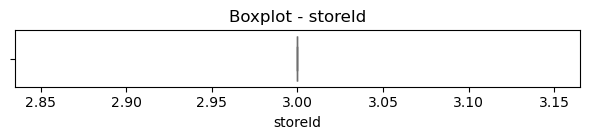

📌 visit_count
 - Median: 1.00
 - Max: 22.00 / Min: 1.00
 - Mean ± 3*Std: [-5.38, 9.97]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 8건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-0.50, 3.50]
 - IQR 기준 이상값: 42건
   → 🚨 이상값 의심됨 (IQR 기준)



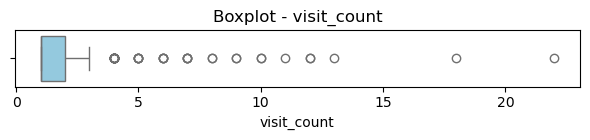

📌 avg_revisit_days
 - Median: 8.68
 - Max: 409.03 / Min: 0.00
 - Mean ± 3*Std: [-172.52, 247.58]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 4건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-79.75, 133.75]
 - IQR 기준 이상값: 7건
   → 🚨 이상값 의심됨 (IQR 기준)



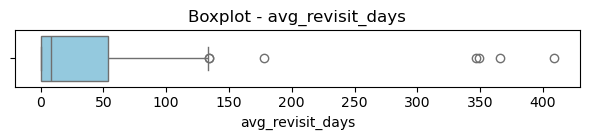

📌 pagerank
 - Median: 1.20
 - Max: 4.99 / Min: 0.39
 - Mean ± 3*Std: [-0.62, 3.38]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 8건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-0.05, 2.65]
 - IQR 기준 이상값: 11건
   → 🚨 이상값 의심됨 (IQR 기준)



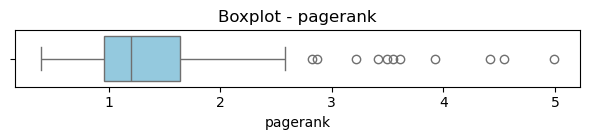

📌 degree
 - Median: 1.20
 - Max: 35.00 / Min: 0.20
 - Mean ± 3*Std: [-6.95, 11.21]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 3건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-1.40, 5.00]
 - IQR 기준 이상값: 17건
   → 🚨 이상값 의심됨 (IQR 기준)



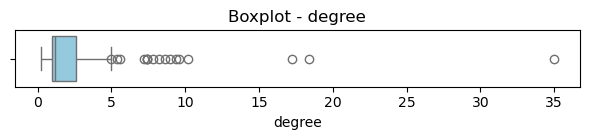

📌 betweenness
 - Median: 0.00
 - Max: 1375.67 / Min: 0.00
 - Mean ± 3*Std: [-305.73, 351.54]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 4건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [0.00, 0.00]
 - IQR 기준 이상값: 62건
   → 🚨 이상값 의심됨 (IQR 기준)



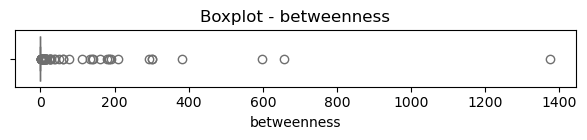

📌 closeness
 - Median: 1.00
 - Max: 1.00 / Min: 0.19
 - Mean ± 3*Std: [0.17, 1.52]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [0.17, 1.50]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



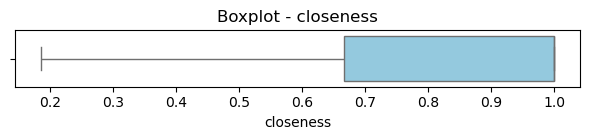

📌 eigen
 - Median: 0.01
 - Max: 0.05 / Min: 0.00
 - Mean ± 3*Std: [-0.01, 0.03]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 5건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [-0.00, 0.03]
 - IQR 기준 이상값: 11건
   → 🚨 이상값 의심됨 (IQR 기준)



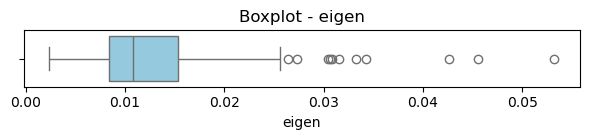


📦 [범주형 변수 희귀값 확인] (비율 < 1.0%)
 - customerId: 희귀값 272개 (100.0%) → ⚠️ 희귀 범주 존재
 - fullName: 희귀값 159개 (58.5%) → ⚠️ 희귀 범주 존재


In [48]:
detailed_outlier_report(three)

# storeId '5' 고객
* 비둘기는 멍청해보여
* 경북 경산시 대학로 271

In [43]:
five = cus_marketing_score_df[cus_marketing_score_df['storeId']==5]
five

,customerId,fullName,storeId,visit_count,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen
174,01H9CY93FVA1J4SA755K6JNAQ8,박*미,5,8,53.857741,2.005196,4.4,12.0,0.833333,0.060776
199,01H9W8SZ19CAVG54Z4XGR2DWTR,서*곤,5,11,47.193573,1.739336,4.0,8.0,0.625000,0.055251
331,01HAKWDHX2VCAXR366TM0W6R1M,문*영,5,2,7.961827,0.961240,0.2,0.0,1.000000,0.026889
389,01HARR323KHW4NDARB2VGHBQYD,오*윤,5,4,8.329685,1.166087,3.2,8.0,0.833333,0.031479
409,01HATVZ2DFPPC3ERXCYXMVXXS6,김*하,5,7,4.688889,1.342257,7.0,0.0,0.750000,0.041827
1050,01HBN281X9M8GMFYMCXQ0CS199,주*서,5,6,70.789652,2.414777,2.8,26.0,1.000000,0.068622
1108,01HBQFZMCNA4CBAXPWPEXVNHFT,김*서,5,1,NaN,0.961240,2.0,0.0,1.000000,0.026889
1710,01HCPHYV4BMEF2P6FNBQK9T9Q3,이*현,5,3,213.474466,0.961240,0.2,0.0,1.000000,0.026889
6364,01J3HJP3J0FTDF64H5XR17H8P2,김*영,5,6,7.614634,2.990848,5.2,210.0,0.409836,0.081950
6833,01J64PVW1MSXS4BSG7WW35CJZZ,G***t,5,1,NaN,0.862118,1.0,0.0,0.428571,0.028392


# storeId '10028' 고객
* 88식당(영대점)
* 경상북도 경산시 대학로53길 12-3(대동)

In [45]:
onezero28 = cus_marketing_score_df[cus_marketing_score_df['storeId']==10028]
onezero28

,customerId,fullName,storeId,visit_count,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen
86,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,10028,1,NaN,0.961240,0.2,0.0,1.000000,0.008516
332,01HAKWDHX2VCAXR366TM0W6R1M,문*영,10028,1,NaN,0.961240,1.0,0.0,1.000000,0.008516
390,01HARR323KHW4NDARB2VGHBQYD,오*윤,10028,1,NaN,1.437412,1.0,0.0,0.428571,0.016483
1109,01HBQFZMCNA4CBAXPWPEXVNHFT,김*서,10028,2,0.878986,1.278886,0.4,0.0,1.000000,0.011612
5906,01J0JM2DFHVBKZSKHJY53BW8TQ,정*윤,10028,2,0.218913,2.445814,1.6,10.0,0.666667,0.026405
...,...,...,...,...,...,...,...,...,...,...
10713,01JDE567X0RBEVN44XR1J3N3S3,김*태,10028,2,0.997250,0.961240,0.2,0.0,1.000000,0.008516
10723,01JDE94A2PH0HG7JWGQHQB5HQX,신*명,10028,2,0.418740,0.976524,2.0,0.0,0.083196,0.013502
10724,01JDE94SDGZGA6ZEMNTCBT6D0E,박*영,10028,3,21.567448,2.480431,5.2,8223.0,0.090519,0.035323
10860,01JDPA7N5349FHRTRJXH1HBM74,김*현,10028,11,10.689828,3.740961,11.2,15904.0,0.077044,0.036873
